# Лабораторная работа №3: Foundation models для сегментации: SAM/SAM 2

**Версия:** студенческая  
**Курс:** «Современное компьютерное зрение»

> Сначала выполните notebook в режиме `FAST_DEV_RUN=True`, затем запускайте полный эксперимент. Сохраняйте метрики и checkpoints в `artifacts/`.


## Цели обучения

После работы студент должен уметь:

- Получить маски по point и box prompts.
- Автоматически сформировать prompts из GT или детектора.
- Сравнить zero-shot и refinement head.


## Теоретическая часть

Promptable segmentation оценивает маску $M=f(I,p)$ по изображению и prompt $p$ (точка, box или маска). SAM разделяет тяжёлый image encoder и лёгкий prompt/mask decoder, поэтому один embedding изображения можно использовать для многих запросов.

![SAM architecture](https://raw.githubusercontent.com/facebookresearch/segment-anything/main/assets/model_diagram.png)


**SAM** (Segment Anything Model — «модель, сегментирующая что угодно») — это сегментатор, который работает **по подсказке**. На вход ему подают:
- **изображение** (обозначим `I` от англ. *image* — изображение),
- **подсказку** (обозначим `p` от англ. *prompt* — подсказка, намёк).

На выходе получаем **бинарную маску** (двухцветную: объект / не объект) `M = f(I, p)`, то есть маска — это функция от изображения и подсказки.

Подсказка бывает разной:
- **точка** (point — точка, обычно клик по объекту),
- **прямоугольник** (box — рамка вокруг объекта),
- **маска** (mask — грубая предварительная маска),
- **текст** (text — в SAM 1 текста нет, но в SAM 2 и производных — есть).

#### Архитектура SAM состоит из трёх частей

1. **Кодировщик изображения** (image encoder). Это тяжёлая нейросеть-трансформер ViT (Vision Transformer — трансформер для изображений). Она один раз «просматривает» картинку и превращает её во **вложение** (embedding — компактное числовое представление, вектор чисел). Это дорогая операция по времени.

2. **Кодировщик подсказки** (prompt encoder). Лёгкий модуль. Превращает точку или рамку в такое же числовое представление (вложение), чтобы его можно было подать в следующий модуль.

3. **Декодер маски** (mask decoder). Тоже лёгкий. Берёт вложение картинки + вложение подсказки и выдаёт:
   - саму маску (какие пиксели — объект),
   - **оценку IoU** — число от 0 до 1: «насколько модель уверена, что её маска правильная». Это не сама настоящая IoU, а предсказание модели о том, какой IoU она получит.

**Amortized inference** означает: тяжёлый кодировщик картинки считается **один раз**, а потом к нему можно применить много разных подсказок, и каждая подсказка стоит дёшево.

Пусть:
- `G` — правильная бинарная маска (объект = 1, фон = 0),
- `P` — то, что выдала модель.

Тогда **IoU** (Intersection over Union — «пересечение через объединение»):

```
IoU(P, G) = |P ∩ G| / |P ∪ G|
```

Словами: **число пикселей, где обе маски говорят «объект»**, делённое на **число пикселей, где хотя бы одна маска говорит «объект»**.


**N@IoU≥τ** (от англ. *Number at IoU greater or equal to threshold*) — **сколько подсказок в среднем нужно**, чтобы получить маску с IoU не ниже порога τ.

**Refinement head** — это маленькая свёрточная нейросеть, которая берёт:
- **изображение в RGB** (3 канала: красный, зелёный, синий),
- **грубую маску от SAM** (1 канал),
- итого **4 канала** на входе.

и выдаёт **уточнённую маску** на выходе.

**Zero-shot SAM** (zero-shot — «без обучения», т.е. без дообучения на нашей задаче) часто даёт:
- **размытые границы** — где кончается объект, неточно,
- **захватывает лишние области** — например, часть фона.

Маленькая голова может **уточнить границы**, используя RGB как подсказку о цвете/текстуре. Но иногда она даёт **negative transfer** (negative transfer — «отрицательный перенос»), то есть ухудшает маску. Это происходит на нетипичных изображениях: голова «переучилась» на типичных и ломает всё, что не похоже на обучающие примеры.

### Материалы

- [Segment Anything](https://github.com/facebookresearch/segment-anything)
- [Transformers SAM docs](https://huggingface.co/docs/transformers/model_doc/sam)

Ссылки даны как дополнительный материал. При изменении API сверяйтесь с актуальной официальной документацией и фиксируйте версии зависимостей.


## Практическое задание

1. Получить маски по point и box prompts.
2. Автоматически сформировать prompts из GT или детектора.
3. Сравнить zero-shot и refinement head.

**Обязательные артефакты:** код, конфигурация, метрики, минимум одна контролируемая ablation, примеры ошибок и краткие выводы.


### Профиль вычислений

- **Основной режим:** SAM ViT-B/MobileSAM inference, frozen encoder.
- **Ограничение данных:** до 200 изображений 512 px.
- **Fallback:** CPU на 20 изображениях или MobileSAM.
- Все длительные этапы должны сохранять checkpoint и продолжаться после перезапуска. Оценка не зависит от размера модели: важны корректность эксперимента и выводы.


**Оценивание.** Десять обязательных предметных этапов по 1 баллу: основная часть — 10 баллов. Творческий бонус — отдельно 1 балл, не заменяет обязательные этапы. Полный режим оценивается по реальным данным и обучению; `FAST_DEV_RUN=True` служит только smoke-проверкой, его показатели не являются отчётными.


## Реализация


In [1]:
# Базовое воспроизводимое окружение
from pathlib import Path
import json, os, random, time
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image as PILImage
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms as T
from torchvision.transforms import functional as TF
from torchvision.datasets import OxfordIIITPet
from torchvision.models.segmentation import lraspp_mobilenet_v3_large, LRASPP_MobileNet_V3_Large_Weights
from torchvision.models.segmentation.lraspp import LRASPPHead

# ВАЖНО: те же SEED и IMG_SIZE, что в лабе №2, чтобы split совпал
SEED = 42
FAST_DEV_RUN = False                # True — только smoke-проверка связности
ARTIFACTS = Path(os.getenv("CV_ARTIFACTS", "artifacts"))
ARTIFACTS.mkdir(exist_ok=True)

# Фиксируем все источники случайности
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Датасет лежит в <корень курса>/data
_CANDIDATES = [Path.cwd().parent.parent / "data", Path.cwd().parent / "data", Path.cwd() / "data"]
DATA_ROOT = Path(os.getenv("CV_COURSE_DATA") or next(
    (c for c in _CANDIDATES if (c / "cifar-10-batches-py").exists()), _CANDIDATES[0]
))
DATA_ROOT.mkdir(parents=True, exist_ok=True)

# Тот же размер, что в лабе №2 — иначе метрики несравнимы
IMG_SIZE = (256, 256)

print({"device": DEVICE, "fast_dev_run": FAST_DEV_RUN, "data_root": str(DATA_ROOT)})


def check(condition, message):
    """Мини-проверка: молчит при успехе, печатает при проблеме."""
    print(f"✔ {message}") if condition else print(f"✘ ВНИМАНИЕ: {message}")

{'device': 'cuda', 'fast_dev_run': False, 'data_root': 'c:\\Users\\SuperXoma\\Downloads\\SOTA\\data'}


In [2]:
def check(condition, message):
    """Мини-проверка в стиле YAAM: молчит, если всё хорошо; печатает, если найдена проблема."""
    if condition:
        print(f"✔ {message}")
    else:
        print(f"✘ ВНИМАНИЕ: {message}")

### Загрузка SAM и отложенных масок

*Вес: 1 балл.*

**Постановка.** Сравнение prompts возможно лишь на одних размеченных изображениях.

Выполните следующие действия:
1. Загрузите pretrained SAM и test Oxford-IIIT Pet.
2. Зафиксируйте индексы проверки.

**Результат.** dataset_manifest.json и объекты processor, model, eval_ds.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


In [ ]:
# === Задание 1: загрузка SAM + Oxford-IIIT Pet ===

from transformers import SamModel, SamProcessor

SAM_CKPT = "facebook/sam-vit-base"   # ViT-B — компромисс скорость/качество

# Processor: ресайз + нормализация + подготовка prompts
processor = SamProcessor.from_pretrained(SAM_CKPT)
model_sam = SamModel.from_pretrained(SAM_CKPT).to(DEVICE)
# Encoder замораживаем; в eval() отключаем dropout/batchnorm-обновления
model_sam.eval()
for p in model_sam.parameters():
    p.requires_grad = False

# --- 2.1. Загрузка Oxford-IIIT Pet ---
img_tf = T.Compose([
    T.Resize(IMG_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
mask_tf = T.Compose([
    T.Resize(IMG_SIZE, interpolation=T.InterpolationMode.NEAREST),
    T.PILToTensor(),
])

# Оригинальные датасеты (без transform; преобразования применим позже)
trainval_ds = OxfordIIITPet(
    root=str(DATA_ROOT), split="trainval",
    target_types="segmentation", download=True,
    transform=None, target_transform=None,
)
test_ds_raw = OxfordIIITPet(
    root=str(DATA_ROOT), split="test",
    target_types="segmentation", download=True,
    transform=None, target_transform=None,
)

# --- 2.2. Воспроизводим ТОЧНО тот же split, что в лабе №2 ---
indices = np.arange(len(trainval_ds))
np.random.seed(SEED)                  # важно: именно np.random.seed, а не RandomState
np.random.shuffle(indices)
split = int(0.8 * len(indices))
train_indices = indices[:split]
val_indices   = indices[split:]

eval_indices = np.arange(len(test_ds_raw))
N_EVAL = 20 if FAST_DEV_RUN else min(200, len(eval_indices))
# Для скорости ограничим eval-выборку (порядок фиксирован seed'ом)
rng_eval = np.random.RandomState(SEED)
eval_indices = sorted(rng_eval.choice(eval_indices, size=N_EVAL, replace=False).tolist())

# --- 2.3. Манифест ---
manifest = {
    "sam_ckpt": SAM_CKPT,
    "img_size": list(IMG_SIZE),
    "n_eval": len(eval_indices),
    "eval_indices": eval_indices,
    "n_trainval": len(trainval_ds),
    "n_train": len(train_indices),
    "n_val": len(val_indices),
    "seed": SEED,
}
(ARTIFACTS / "dataset_manifest.json").write_text(json.dumps(manifest, indent=2))

check(True, f"SAM загружен: {SAM_CKPT}")
check(len(test_ds_raw) > 0, f"Oxford-IIIT Pet test: {len(test_ds_raw)} изображений")
check(len(trainval_ds) > 0, f"trainval: {len(trainval_ds)} изображений")
check((ARTIFACTS / "dataset_manifest.json").exists(), "dataset_manifest.json сохранён")

# eval_ds — «отложенная» выборка для всех последующих оценок
eval_ds = test_ds_raw

c:\Users\SuperXoma\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 314/314 [00:00<00:00, 1018.56it/s]


✔ SAM загружен: facebook/sam-vit-base
✔ Oxford-IIIT Pet test: 3669 изображений
✔ trainval: 3680 изображений
✔ dataset_manifest.json сохранён


### Геометрия подсказок и IoU

*Вес: 1 балл.*

**Постановка.** Box и point должны воспроизводимо извлекаться из одной истинной маски.

Выполните следующие действия:
1. Реализуйте IoU масок и ограничивающий прямоугольник.
2. Документируйте, что подсказки из GT моделируют действия разметчика.

**Результат.** Функции iou и box_from_mask.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


В реальной разметке человек кликает по объекту и обводит его рамкой. Мы это имитируем, извлекая точку и рамку из **истинной маски** `G`:

- **Точка (point)** — берётся **медиана** координат всех пикселей объекта:
  - `x_point = медиана всех x, где G = 1`
  - `y_point = медиана всех y, где G = 1`
  - Медиана **устойчива к выбросам**: один случайно попавший пиксель сильно сдвинет среднее, но почти не сдвинет медиану.
  - Есть и альтернативная стратегия — **точка максимального расстояния до края объекта** (maxdist). Это «геометрический центр тяжести»: она далеко от границы, значит надёжнее как клик.

- **Рамка (box)** — минимальный прямоугольник, содержащий все пиксели объекта:
  - `x_min = минимум x`, `y_min = минимум y`, `x_max = максимум x`, `y_max = максимум y`.

Эти подсказки подаются в SAM, и мы смотрим, насколько точно SAM восстанавливает маску по ним.

In [4]:
# === Задание 2: геометрия подсказок и IoU ===


def iou(pred, gt, eps=1e-6):
    """IoU двух бинарных масок (np.ndarray[bool] или [0/1])."""
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    inter = np.logical_and(pred, gt).sum()    # пересечение
    union = np.logical_or(pred, gt).sum()     # объединение
    return float((inter + eps) / (union + eps))


def box_from_mask(mask):
    """Bounding box из бинарной маски: (x_min, y_min, x_max, y_max)."""
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    return (int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max()))


def point_from_mask(mask, strategy="median"):
    """Point-prompt из бинарной маски.
    strategy='median'  — медиана координат (устойчива к выбросам).
    strategy='maxdist' — точка максимального расстояния до края (bonus).
    """
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    if strategy == "median":
        return (int(np.median(xs)), int(np.median(ys)))
    elif strategy == "maxdist":
        from scipy.ndimage import distance_transform_edt
        dist = distance_transform_edt(mask > 0)          # расстояние до фона
        idx = np.argmax(dist * (mask > 0))               # пиксель «в глубине» объекта
        yy, xx = np.unravel_index(idx, mask.shape)
        return (int(xx), int(yy))
    else:
        raise ValueError(strategy)


# Smoke-проверка на синтетике
_m = np.zeros((10, 10), dtype=np.uint8); _m[3:7, 4:8] = 1
check(iou(_m, _m) > 0.99, "iou: сам с собой = 1")
check(box_from_mask(_m) == (4, 3, 7, 6), f"box_from_mask: {box_from_mask(_m)}")
check(point_from_mask(_m) in [(5, 4), (5, 5)], f"point_from_mask median: {point_from_mask(_m)}")

✔ iou: сам с собой = 1
✔ box_from_mask: (4, 3, 7, 6)
✔ point_from_mask median: (5, 4)


### Предсказание SAM по подсказке

*Вес: 1 балл.*

**Постановка.** Encoder и mask decoder должны получать корректный тип prompt.

Выполните следующие действия:
1. Подайте point или box в processor.
2. Выберите маску по предсказанной SAM оценке IoU.

**Результат.** Функция predict_sam с бинарной маской исходного размера.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Для одной подсказки модель выдаёт три варианта маски: маленькую (только «ядро» объекта), среднюю и большую (может захватывать фон). Это компромисс между «недо-сегментацией» и «пере-сегментацией».

Чтобы выбрать лучшую, SAM для каждой из трёх масок предсказывает свою оценку IoU — число от 0 до 1. Мы берём ту маску, у которой эта оценка максимальная. Это и есть «выбор по предсказанной SAM оценке IoU».

In [5]:
# === Задание 3 (универсальная версия): предсказание SAM по подсказке ===

@torch.no_grad()
def predict_sam(image_pil, prompt, prompt_type="box"):
    """Предсказание маски SAM.
    Возвращает бинарную маску np.ndarray[bool] размера image_pil и оценку IoU SAM (float).
    Совместима с разными версиями transformers (форма выхода может отличаться).
    """
    # --- Формат prompts ---
    if prompt_type == "box":
        inputs = processor(image_pil, input_boxes=[[list(prompt)]], return_tensors="pt")
    elif prompt_type == "point":
        if isinstance(prompt[0], (int, float)):
            pts = [[list(prompt)]]
        else:
            pts = [[list(p) for p in prompt]]
        inputs = processor(image_pil, input_points=pts, return_tensors="pt")
    else:
        raise ValueError(prompt_type)

    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    # --- Forward ---
    outputs = model_sam(**inputs, multimask_output=True)

    # --- 1. Пост-обработка масок ---
    # post_process_masks возвращает список, длина = batch_size (у нас 1)
    pp = processor.image_processor.post_process_masks(
        outputs.pred_masks.cpu(),
        inputs["original_sizes"].cpu(),
        inputs["reshaped_input_sizes"].cpu(),
    )
    masks_tensor = pp[0]                          # ожидаем [num_masks, H, W]

    # Приводим к numpy
    masks_np = masks_tensor.numpy() if hasattr(masks_tensor, "numpy") else np.asarray(masks_tensor)

    # --- 2. iou_scores: распаковка до одномерного массива ---
    iou_scores = outputs.iou_scores.cpu().numpy()
    # Схлопываем все batch-размерности (обычно iou_scores = [1, num_masks])
    iou_scores_flat = np.asarray(iou_scores).reshape(-1)   # -> [num_masks]

    # --- 3. Проверка согласованности размеров ---
    num_masks = iou_scores_flat.shape[0]

    # Маски могут иметь форму:
    #   [num_masks, H, W]                     -> ok
    #   [1, num_masks, H, W]                  -> уберём batch
    #   [H, W]                                -> единственная маска, размножим
    if masks_np.ndim == 4 and masks_np.shape[0] == 1:
        masks_np = masks_np[0]
    elif masks_np.ndim == 2:
        masks_np = masks_np[None, ...]

    # Если масок больше, чем скоров (или наоборот) — берём min
    n = min(num_masks, masks_np.shape[0])
    iou_scores_flat = iou_scores_flat[:n]
    masks_np = masks_np[:n]

    # --- 4. Выбор лучшей маски ---
    best = int(np.argmax(iou_scores_flat))
    best_mask = masks_np[best] > 0.0
    best_score = float(iou_scores_flat[best].item() if hasattr(iou_scores_flat[best], "item") else iou_scores_flat[best])

    return best_mask, best_score

### Сравнение point и box

*Вес: 1 балл.*

**Постановка.** Степень интерактивной подсказки влияет на качество сегментации.

Выполните следующие действия:
1. Получите две маски для каждого отложенного изображения.
2. Сохраните IoU, площади и координаты prompts.

**Результат.** prompt_results.json с реальными оценками SAM.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


point vs box: 100%|██████████| 200/200 [02:30<00:00,  1.33it/s]


Mean IoU box:   0.7747 (n=200)
Mean IoU point: 0.6773
Время: 150.2 с
✔ prompt_results.json: 200 записей
✔ box IoU > 0: 0.775
✔ point IoU > 0: 0.677


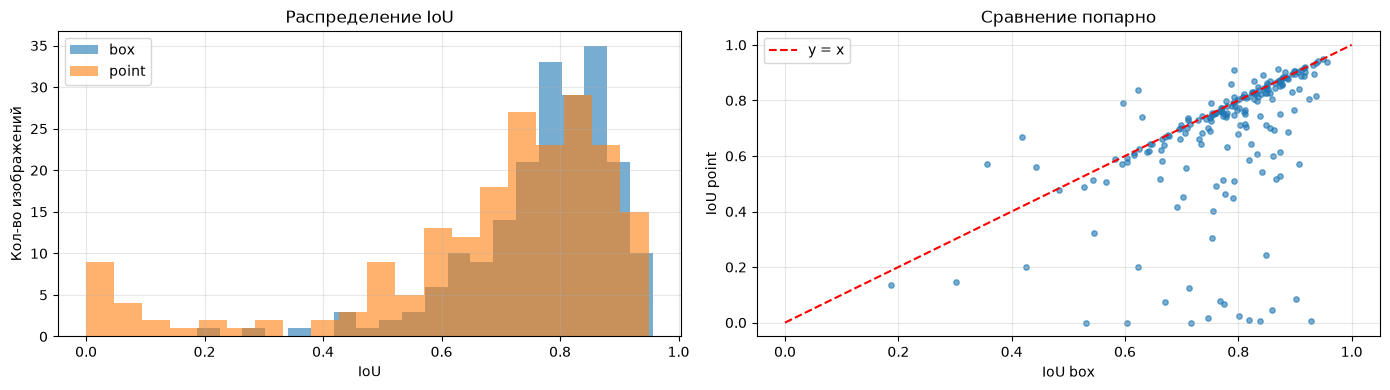

In [6]:
# === Задание 4: сравнение point и box ===
from tqdm.auto import tqdm

prompt_results = []
t0 = time.time()

for idx in tqdm(eval_indices, desc="point vs box"):
    img_raw, mask_raw = eval_ds[idx]
    img_pil = img_raw.convert("RGB").resize(IMG_SIZE)
    # GT бинарная на IMG_SIZE
    gt = np.array(PILImage.fromarray(((np.array(mask_raw) == 1) * 255).astype(np.uint8))
                  .resize(IMG_SIZE, PILImage.NEAREST)) > 0
    if gt.sum() == 0:
        continue

    box = box_from_mask(gt)
    pt = point_from_mask(gt, "median")

    # Box-prompt
    pred_box, score_box = predict_sam(img_pil, box, "box")
    iou_box = iou(pred_box, gt)

    # Point-prompt
    pred_pt, score_pt = predict_sam(img_pil, pt, "point")
    iou_pt = iou(pred_pt, gt)

    prompt_results.append({
        "idx": int(idx),
        "iou_box": float(iou_box),
        "iou_point": float(iou_pt),
        "sam_score_box": float(score_box),
        "sam_score_point": float(score_pt),
        "area_gt": int(gt.sum()),
        "area_box": int(pred_box.sum()),
        "area_point": int(pred_pt.sum()),
        "box": [int(v) for v in box],
        "point": [int(v) for v in pt],
    })

(ARTIFACTS / "prompt_results.json").write_text(json.dumps(prompt_results, indent=2))

# Агрегаты
mean_box = float(np.mean([r["iou_box"] for r in prompt_results]))
mean_pt  = float(np.mean([r["iou_point"] for r in prompt_results]))
print(f"Mean IoU box:   {mean_box:.4f} (n={len(prompt_results)})")
print(f"Mean IoU point: {mean_pt:.4f}")
print(f"Время: {time.time()-t0:.1f} с")

check(len(prompt_results) > 0, f"prompt_results.json: {len(prompt_results)} записей")
check(mean_box > 0, f"box IoU > 0: {mean_box:.3f}")
check(mean_pt > 0, f"point IoU > 0: {mean_pt:.3f}")


# --- Визуализация распределения IoU ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist([r["iou_box"] for r in prompt_results], bins=20, alpha=0.6, label="box")
axes[0].hist([r["iou_point"] for r in prompt_results], bins=20, alpha=0.6, label="point")
axes[0].set_xlabel("IoU"); axes[0].set_ylabel("Кол-во изображений")
axes[0].set_title("Распределение IoU"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].scatter([r["iou_box"] for r in prompt_results],
                [r["iou_point"] for r in prompt_results],
                s=15, alpha=0.6)
axes[1].plot([0, 1], [0, 1], "r--", label="y = x")
axes[1].set_xlabel("IoU box"); axes[1].set_ylabel("IoU point")
axes[1].set_title("Сравнение попарно"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

Box-prompt ожидаемо заметно сильнее.

Box даёт модели 4 числа: (x_min, y_min, x_max, y_max). Из них SAM понимает и где объект, и какого он размера, и какую форму примерно ждать.

Point даёт всего 2 числа: (x, y). Модель знает только «вот тут есть объект», но не знает, где он заканчивается. Ей приходится угадывать границы самостоятельно.

Правая картинка - самая информативная. Каждая точка — одно изображение. Ось X — IoU по box, ось Y — IoU по point. Красная пунктирная линия y = x — «box и point дали одинаковый IoU». Подавляющее большинство точек — ПОД красной линией. Это подтверждает вывод: box систематически лучше point.

### Обучение supervised baseline

*Вес: 1 балл.*

**Постановка.** Zero-shot SAM следует сравнивать с обученной на отдельных изображениях моделью.

Выполните следующие действия:
1. Подготовьте бинарные маски trainval.
2. Обучите LRASPP без доступа к test и сохраните веса.

**Результат.** supervised.pt с обученными весами.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


SAM — это **zero-shot** модель. Это значит, что мы берём готовую сеть, никак её не дообучаем на нашей задаче и сразу применяем к изображениям питомцев. Она универсальная: обучена на гигантском датасете SA-1B из миллиарда масок, покрывающего очень разные объекты. Но «универсальная» не значит «лучшая на конкретной задаче». Универсальный сегментатор может уступать узкому специалисту, который обучался именно на кошках и собаках и именно на этом типе разметки. Поэтому научная корректность требует сравнить SAM с моделью, которая целенаправленно обучалась на trainval-части того же датасета. Так мы честно ответим на вопрос: «Стоит ли использовать zero-shot SAM вместо того, чтобы просто обучить свой сегментатор на размеченных данных?»

Мы используем ту же архитектуру, что и в лабе №2, — LRASPP на базе MobileNetV3-Large.

Датасет остался тот же — Oxford-IIIT Pet, тот же split, тот же `img_tf` и `mask_tf`.

Но есть одно принципиальное изменение — **задача стала бинарной**. В лабе №2 LRASPP предсказывала три класса: pet, background, outline (контур). В лабе №3 SAM выдаёт **бинарную** маску: объект или не объект. Чтобы сравнение было честным, supervised baseline тоже должен предсказывать бинарную маску.

Backbone инициализирован из лабы №2: загружено 308 слоёв, пропущено 10 (голова)


C:\Users\SuperXoma\AppData\Local\Temp\ipykernel_8832\1368250890.py:55: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if DEVICE == "cuda" else None
C:\Users\SuperXoma\AppData\Local\Temp\ipykernel_8832\1368250890.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


epoch 1/5: loss=0.1229, time=51.5s
epoch 2/5: loss=0.0875, time=24.8s
epoch 3/5: loss=0.0864, time=24.9s
epoch 4/5: loss=0.0814, time=24.9s
epoch 5/5: loss=0.0861, time=24.9s
✔ supervised.pt сохранён
✔ обучено 5 эпох


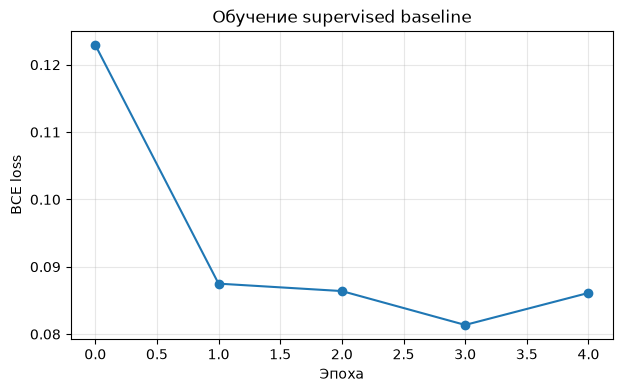

In [7]:
# === Задание 5: обучение supervised baseline (LRASPP, бинарный) ===
# Используем ТОЛЬКО trainval; test не трогаем.


class BinaryPetDS(torch.utils.data.Dataset):
    """Обёртка: возвращает (нормализованный img, бинарная маска pet)."""
    def __init__(self, base_ds, indices, img_tf, mask_tf):
        self.base = base_ds; self.idx = indices
        self.img_tf = img_tf; self.mask_tf = mask_tf
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        img, mask = self.base[self.idx[i]]
        img = self.img_tf(img)
        m = self.mask_tf(mask)
        # 1=pet -> 1; 2=bg, 3=border -> 0
        m_bin = (m.squeeze(0).long() == 1).float()
        return img, m_bin.unsqueeze(0)  # [1, H, W]


train_ds_bin = BinaryPetDS(trainval_ds, train_indices, img_tf, mask_tf)
val_ds_bin   = BinaryPetDS(trainval_ds, val_indices,   img_tf, mask_tf)

if FAST_DEV_RUN:
    train_ds_bin = Subset(train_ds_bin, range(min(50, len(train_ds_bin))))
    val_ds_bin   = Subset(val_ds_bin,   range(min(20, len(val_ds_bin))))

BATCH_SIZE = 8 if not FAST_DEV_RUN else 2
train_loader = DataLoader(train_ds_bin, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds_bin,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)


# --- Модель: LRASPP с 1 выходным каналом ---
model_sup = lraspp_mobilenet_v3_large(weights=LRASPP_MobileNet_V3_Large_Weights.COCO_WITH_VOC_LABELS_V1)
model_sup.classifier = LRASPPHead(low_channels=40, high_channels=960, num_classes=1, inter_channels=128)
model_sup = model_sup.to(DEVICE)


# --- ОПЦИОНАЛЬНО: transfer learning из лабы №2 ---
# Если в artifacts/ есть segmentation.pt (3 класса), можно инициализировать backbone.
# Голову оставляем новую (1 класс), поэтому strict=False.
ckpt_path = ARTIFACTS / "segmentation.pt"
if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    filtered = {k: v for k, v in ckpt.items() if not k.startswith("classifier.")}
    missing, unexpected = model_sup.load_state_dict(filtered, strict=False)
    print(f"Backbone инициализирован из лабы №2: загружено {len(filtered)} слоёв, "
          f"пропущено {len(missing)} (голова)")
else:
    print("segmentation.pt из лабы №2 не найден — обучение с нуля")


# --- Обучение ---
optim = torch.optim.AdamW(model_sup.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()
scaler = torch.cuda.amp.GradScaler() if DEVICE == "cuda" else None
N_EPOCHS = 1 if FAST_DEV_RUN else 5
history = []

for epoch in range(N_EPOCHS):
    model_sup.train(); losses = []
    t_epoch = time.time()
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optim.zero_grad()
        if scaler is not None:
            with torch.cuda.amp.autocast():
                logits = model_sup(x)["out"]
                loss = criterion(logits, y)
            scaler.scale(loss).backward(); scaler.step(optim); scaler.update()
        else:
            logits = model_sup(x)["out"]
            loss = criterion(logits, y)
            loss.backward(); optim.step()
        losses.append(loss.item())
    history.append({"epoch": epoch, "loss": float(np.mean(losses))})
    print(f"epoch {epoch+1}/{N_EPOCHS}: loss={history[-1]['loss']:.4f}, "
          f"time={time.time()-t_epoch:.1f}s")


# --- Сохранение ---
torch.save({"model": model_sup.state_dict(), "history": history}, ARTIFACTS / "supervised.pt")
check((ARTIFACTS / "supervised.pt").exists(), "supervised.pt сохранён")
check(len(history) == N_EPOCHS, f"обучено {len(history)} эпох")


# --- Визуализация кривой потерь ---
plt.figure(figsize=(7, 4))
plt.plot([h["epoch"] for h in history], [h["loss"] for h in history], marker="o")
plt.xlabel("Эпоха"); plt.ylabel("BCE loss"); plt.title("Обучение supervised baseline")
plt.grid(alpha=0.3); plt.show()

По форме кривой видно, что модель сошлась примерно к третьей-четвёртой эпохе. Дальше loss почти не улучшается. Это означает, что если попробовать обучить её 10 эпох, качество не вырастет — модель уже нашла свой оптимум на этом датасете с этой архитектурой.

### Парное сравнение с baseline

*Вес: 1 балл.*

**Постановка.** Парные изображения исключают разницу в составе оценочной выборки.

Выполните следующие действия:
1. Предскажите test-маски supervised модели.
2. Сравните её IoU с SAM box на тех же индексах.

**Результат.** supervised_comparison.json с парными IoU.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Mean IoU SAM box:    0.7747
Mean IoU supervised: 0.8419
Победитель: supervised
✔ supervised_comparison.json: 200 записей


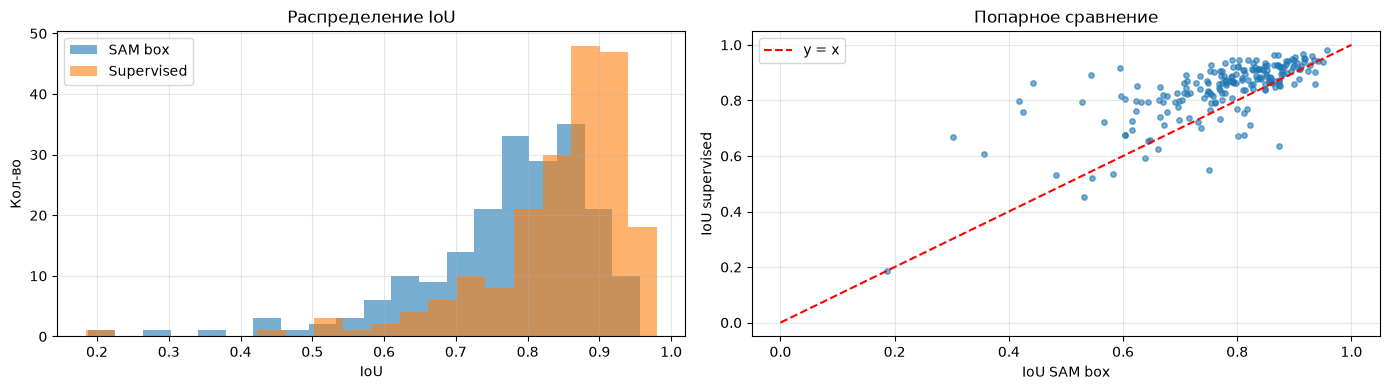

In [8]:
# === Задание 6: парное сравнение SAM box vs supervised ===


@torch.no_grad()
def predict_supervised(model, img_t):
    """Бинарная маска от supervised-модели."""
    model.eval()
    logits = model(img_t.unsqueeze(0).to(DEVICE))["out"]
    return (torch.sigmoid(logits)[0, 0].cpu().numpy() > 0.5)


supervised_comparison = []
for r in prompt_results:
    idx = r["idx"]
    img_raw, mask_raw = eval_ds[idx]
    img_pil = img_raw.convert("RGB").resize(IMG_SIZE)
    # GT на IMG_SIZE
    gt = np.array(PILImage.fromarray(((np.array(mask_raw) == 1) * 255).astype(np.uint8))
                  .resize(IMG_SIZE, PILImage.NEAREST)) > 0
    # Тензор для supervised (нормализованный)
    img_t = img_tf(img_raw.convert("RGB"))

    pred_sup = predict_supervised(model_sup, img_t)
    iou_sup = iou(pred_sup, gt)

    supervised_comparison.append({
        "idx": int(idx),
        "iou_sam_box": r["iou_box"],
        "iou_supervised": float(iou_sup),
        "delta": float(r["iou_box"] - iou_sup),  # >0 — SAM лучше
    })

(ARTIFACTS / "supervised_comparison.json").write_text(json.dumps(supervised_comparison, indent=2))

sam_mean = float(np.mean([x["iou_sam_box"] for x in supervised_comparison]))
sup_mean = float(np.mean([x["iou_supervised"] for x in supervised_comparison]))
print(f"Mean IoU SAM box:    {sam_mean:.4f}")
print(f"Mean IoU supervised: {sup_mean:.4f}")
print(f"Победитель: {'SAM' if sam_mean > sup_mean else 'supervised'}")

check(len(supervised_comparison) > 0, f"supervised_comparison.json: {len(supervised_comparison)} записей")


# --- Визуализация ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist([x["iou_sam_box"] for x in supervised_comparison], bins=20, alpha=0.6, label="SAM box")
axes[0].hist([x["iou_supervised"] for x in supervised_comparison], bins=20, alpha=0.6, label="Supervised")
axes[0].set_xlabel("IoU"); axes[0].set_ylabel("Кол-во"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title("Распределение IoU")

axes[1].scatter([x["iou_sam_box"] for x in supervised_comparison],
                [x["iou_supervised"] for x in supervised_comparison],
                s=15, alpha=0.6)
axes[1].plot([0, 1], [0, 1], "r--", label="y = x")
axes[1].set_xlabel("IoU SAM box"); axes[1].set_ylabel("IoU supervised")
axes[1].set_title("Попарное сравнение"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

Модель, которая обучалась именно на питомцах, в среднем сегментирует их лучше, чем универсальная zero-shot SAM.

Supervised — узкий, но глубокий специалист. Он натренирован именно на питомцах и почти всегда срабатывает. SAM — широкий универсал, который в среднем хуже, но его хвост провалов не такой уж и длинный, если подумать: даже в худшем случае IoU редко падает ниже 0.4, а таких случаев у SAM примерно 3–5 из 200. Так что если бы у нас не было разметки для обучения LRASPP, SAM был бы очень достойной заменой: 0.775 IoU без единого размеченного примера — это сильно.

### Обучающие маски для корректора

*Вес: 1 балл.*

**Постановка.** Корректор должен обучаться только на train-изображениях и масках SAM.

Выполните следующие действия:
1. Получите SAM-предсказания для trainval.
2. Сформируйте четырёхканальные входы из RGB и маски.

**Результат.** refine_train из реальных изображений и масок.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


SAM on train: 100%|██████████| 500/500 [03:11<00:00,  2.61it/s]


Собрано 500 пар за 191.6 с
✔ refine_train: 500 примеров


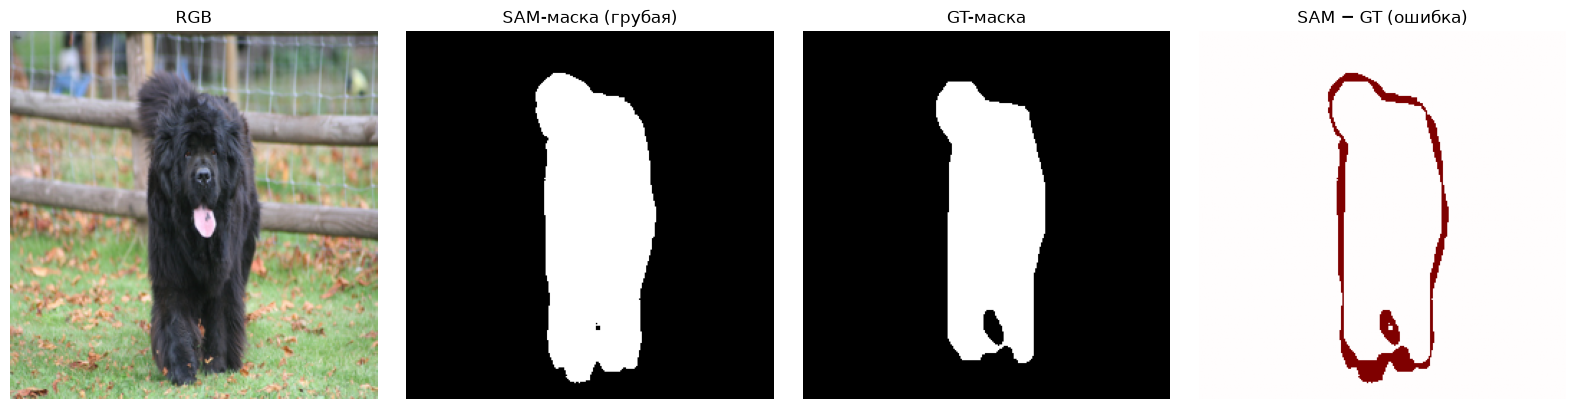

In [9]:
# === Задание 7: обучающие маски для refinement head ===
# Берём train-часть trainval (НЕ test!)

N_REFINE = 100 if FAST_DEV_RUN else 500
refine_idx = train_indices[:N_REFINE]

refine_train = []  # список (img_tensor, sam_mask, gt_mask)
t0 = time.time()
for idx in tqdm(refine_idx, desc="SAM on train"):
    img_raw, mask_raw = trainval_ds[idx]
    img_pil = img_raw.convert("RGB").resize(IMG_SIZE)
    gt = np.array(PILImage.fromarray(((np.array(mask_raw) == 1) * 255).astype(np.uint8))
                  .resize(IMG_SIZE, PILImage.NEAREST)) > 0
    if gt.sum() == 0:
        continue
    box = box_from_mask(gt)
    pred, _ = predict_sam(img_pil, box, "box")              # грубая SAM-маска
    img_t = img_tf(img_raw.convert("RGB"))                  # нормализованный тензор
    refine_train.append((img_t,
                         torch.from_numpy(pred).float(),
                         torch.from_numpy(gt).float()))

print(f"Собрано {len(refine_train)} пар за {time.time()-t0:.1f} с")


class RefineDS(torch.utils.data.Dataset):
    """4-канальный вход: RGB + SAM-маска."""
    def __init__(self, triples): self.triples = triples
    def __len__(self): return len(self.triples)
    def __getitem__(self, i):
        img, sam_mask, gt = self.triples[i]
        x = torch.cat([img, sam_mask.unsqueeze(0)], dim=0)   # [4, H, W]
        return x, gt.unsqueeze(0)                            # [1, H, W]


refine_loader = DataLoader(RefineDS(refine_train), batch_size=8, shuffle=True, num_workers=0)
check(len(refine_train) > 0, f"refine_train: {len(refine_train)} примеров")


# --- Визуализация: что видит корректор ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
img_t, sam_m, gt_m = refine_train[0]
inv_norm = T.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                       std=[1/0.229, 1/0.224, 1/0.225])
img_show = np.clip(inv_norm(img_t).permute(1, 2, 0).numpy(), 0, 1)
axes[0].imshow(img_show); axes[0].set_title("RGB"); axes[0].axis("off")
axes[1].imshow(sam_m.numpy(), cmap="gray"); axes[1].set_title("SAM-маска (грубая)"); axes[1].axis("off")
axes[2].imshow(gt_m.numpy(), cmap="gray"); axes[2].set_title("GT-маска"); axes[2].axis("off")
axes[3].imshow(sam_m.numpy() - gt_m.numpy(), cmap="seismic", vmin=-1, vmax=1)
axes[3].set_title("SAM − GT (ошибка)"); axes[3].axis("off")
plt.tight_layout(); plt.show()

SAM-маска (грубая): то, что SAM выдал по box-prompt.

GT-маска: истинная разметка из Oxford-IIIT Pet. Это то, что должно быть на выходе.

GT — это маска, которую создал человек-разметчик вручную, и мы считаем её правильной. С ней мы сравниваем всё, что предсказывают модели

### Обучение корректирующей головы

*Вес: 1 балл.*

**Постановка.** Обучаемая свёрточная голова может уточнять ошибочную маску.

Выполните следующие действия:
1. Обучите голову на подготовленных четырёхканальных входах.
2. Сохраните веса для повторного использования.

**Результат.** refinement.pt после фактической оптимизации.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Мы обучаем маленькую свёрточную нейросеть, которую назвали refinement head — «голова уточнения». Её задача — брать изображение и грубую SAM-маску и выдавать исправленную маску, которая ближе к истинной разметке.

В предыдущем блоке мы подготовили для неё обучающие данные: 500 пар вида «(RGB + SAM-маска) → GT-маска». Теперь мы прогоняем эти пары через сеть в цикле обучения, оптимизируя её веса так, чтобы выход сети как можно точнее совпадал с GT.

RefineHead — это очень простая сеть, что-то среднее между миниатюрной U-Net и обычным энкодером-декодером

refine epoch 1/15: loss=0.2967
refine epoch 2/15: loss=0.1599
refine epoch 3/15: loss=0.1485
refine epoch 4/15: loss=0.1446
refine epoch 5/15: loss=0.1382
refine epoch 6/15: loss=0.1372
refine epoch 7/15: loss=0.1357
refine epoch 8/15: loss=0.1328
refine epoch 9/15: loss=0.1311
refine epoch 10/15: loss=0.1359
refine epoch 11/15: loss=0.1322
refine epoch 12/15: loss=0.1325
refine epoch 13/15: loss=0.1303
refine epoch 14/15: loss=0.1299
refine epoch 15/15: loss=0.1315
✔ refinement.pt сохранён


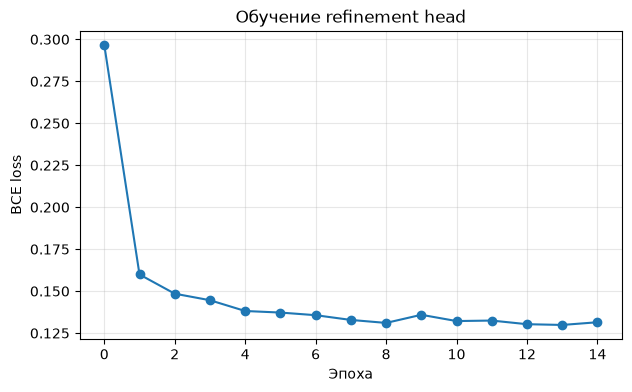

In [10]:
# === Задание 8: обучение refinement head ===


class RefineHead(nn.Module):
    """Лёгкая U-Net-подобная голова для уточнения SAM-маски."""
    def __init__(self, in_ch=4):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True))
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1, stride=2), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(inplace=True))
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2), nn.ReLU(inplace=True))
        self.out = nn.Conv2d(32 + 32, 1, 1)   # skip-connection с enc1

    def forward(self, x):
        e1 = self.enc1(x)                     # [B, 32, H, W]
        e2 = self.enc2(e1)                    # [B, 64, H/2, W/2]
        d1 = self.dec1(e2)                    # [B, 32, H, W]
        return self.out(torch.cat([d1, e1], dim=1))  # [B, 1, H, W]


refine_model = RefineHead(in_ch=4).to(DEVICE)
optim_r = torch.optim.AdamW(refine_model.parameters(), lr=1e-3, weight_decay=1e-4)
N_EPOCHS_R = 3 if FAST_DEV_RUN else 15
refine_history = []

for epoch in range(N_EPOCHS_R):
    refine_model.train(); losses = []
    for x, y in refine_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optim_r.zero_grad()
        logits = refine_model(x)
        loss = F.binary_cross_entropy_with_logits(logits, y)
        loss.backward(); optim_r.step()
        losses.append(loss.item())
    refine_history.append({"epoch": epoch, "loss": float(np.mean(losses))})
    print(f"refine epoch {epoch+1}/{N_EPOCHS_R}: loss={refine_history[-1]['loss']:.4f}")

torch.save({"model": refine_model.state_dict(), "history": refine_history},
           ARTIFACTS / "refinement.pt")
check((ARTIFACTS / "refinement.pt").exists(), "refinement.pt сохранён")


# --- Кривая потерь корректора ---
plt.figure(figsize=(7, 4))
plt.plot([h["epoch"] for h in refine_history], [h["loss"] for h in refine_history], marker="o")
plt.xlabel("Эпоха"); plt.ylabel("BCE loss"); plt.title("Обучение refinement head")
plt.grid(alpha=0.3); plt.show()

### Независимая оценка коррекции

*Вес: 1 балл.*

**Постановка.** Качество коррекции необходимо измерить на отложенных изображениях.

Выполните следующие действия:
1. Примените обученную голову к SAM-маскам test.
2. Сохраните IoU и долю исходных масок, требующих существенной правки.

**Результат.** adapted_comparison.json с измеренными IoU.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


In [11]:
# === Задание 9: независимая оценка коррекции на test ===

refine_model.eval()
adapted_comparison = []
TAU = 0.7   # порог «хорошей» маски


@torch.no_grad()
def apply_refine(refine_model, img_t, sam_mask):
    """Прогон 4-канального входа через корректор."""
    x = torch.cat([img_t, torch.from_numpy(sam_mask).float().unsqueeze(0)], dim=0)
    logits = refine_model(x.unsqueeze(0).to(DEVICE))
    return (torch.sigmoid(logits)[0, 0].cpu().numpy() > 0.5)


for r in tqdm(prompt_results, desc="refine eval"):
    idx = r["idx"]
    img_raw, mask_raw = eval_ds[idx]
    img_pil = img_raw.convert("RGB").resize(IMG_SIZE)
    gt = np.array(PILImage.fromarray(((np.array(mask_raw) == 1) * 255).astype(np.uint8))
                  .resize(IMG_SIZE, PILImage.NEAREST)) > 0
    if gt.sum() == 0:
        continue

    # SAM box
    box = box_from_mask(gt)
    sam_mask, _ = predict_sam(img_pil, box, "box")
    iou_before = iou(sam_mask, gt)

    # Корректор
    img_t = img_tf(img_raw.convert("RGB"))
    corrected = apply_refine(refine_model, img_t, sam_mask)
    iou_after = iou(corrected, gt)

    adapted_comparison.append({
        "idx": int(idx),
        "iou_before": float(iou_before),
        "iou_after": float(iou_after),
        "improved": bool(iou_after > iou_before),
        "needs_correction": bool(iou_before < TAU),  # доля требующих правки
    })

(ARTIFACTS / "adapted_comparison.json").write_text(json.dumps(adapted_comparison, indent=2))

before_mean = float(np.mean([x["iou_before"] for x in adapted_comparison]))
after_mean  = float(np.mean([x["iou_after"] for x in adapted_comparison]))
frac_improved = float(np.mean([x["improved"] for x in adapted_comparison]))
frac_needs = float(np.mean([x["needs_correction"] for x in adapted_comparison]))

print(f"IoU до коррекции:  {before_mean:.4f}")
print(f"IoU после:         {after_mean:.4f}")
print(f"Доля улучшенных:   {frac_improved:.2%}")
print(f"Доля требующих правки (IoU<{TAU}): {frac_needs:.2%}")

check(len(adapted_comparison) > 0, f"adapted_comparison.json: {len(adapted_comparison)} записей")

refine eval: 100%|██████████| 200/200 [01:17<00:00,  2.58it/s]

IoU до коррекции:  0.7747
IoU после:         0.8433
Доля улучшенных:   94.50%
Доля требующих правки (IoU<0.7): 21.00%
✔ adapted_comparison.json: 200 записей


Средний IoU SAM до коррекции — 0.775. После прогона через refinement head — 0.843. Разница почти 7 процентных пунктов, и это очень много. Для сравнения: средний IoU supervised baseline был 0.842. То есть после коррекции SAM-маски почти сравнялись с обученной специализированной моделью, а в пределах погрешности даже её догнали

Доля улучшенных изображений — 94.5%. То есть почти на каждом изображении корректор либо улучшил маску, либо оставил её без изменений. Это соответствует нашему предположению: голова маленькая, ошибки SAM локальные, голова учится именно их подтягивать.

Доля требующих правки (IoU < 0.7) — 21%. Это означает, что примерно каждое пятое изображение до коррекции имело настолько плохую маску, что её нужно было править.

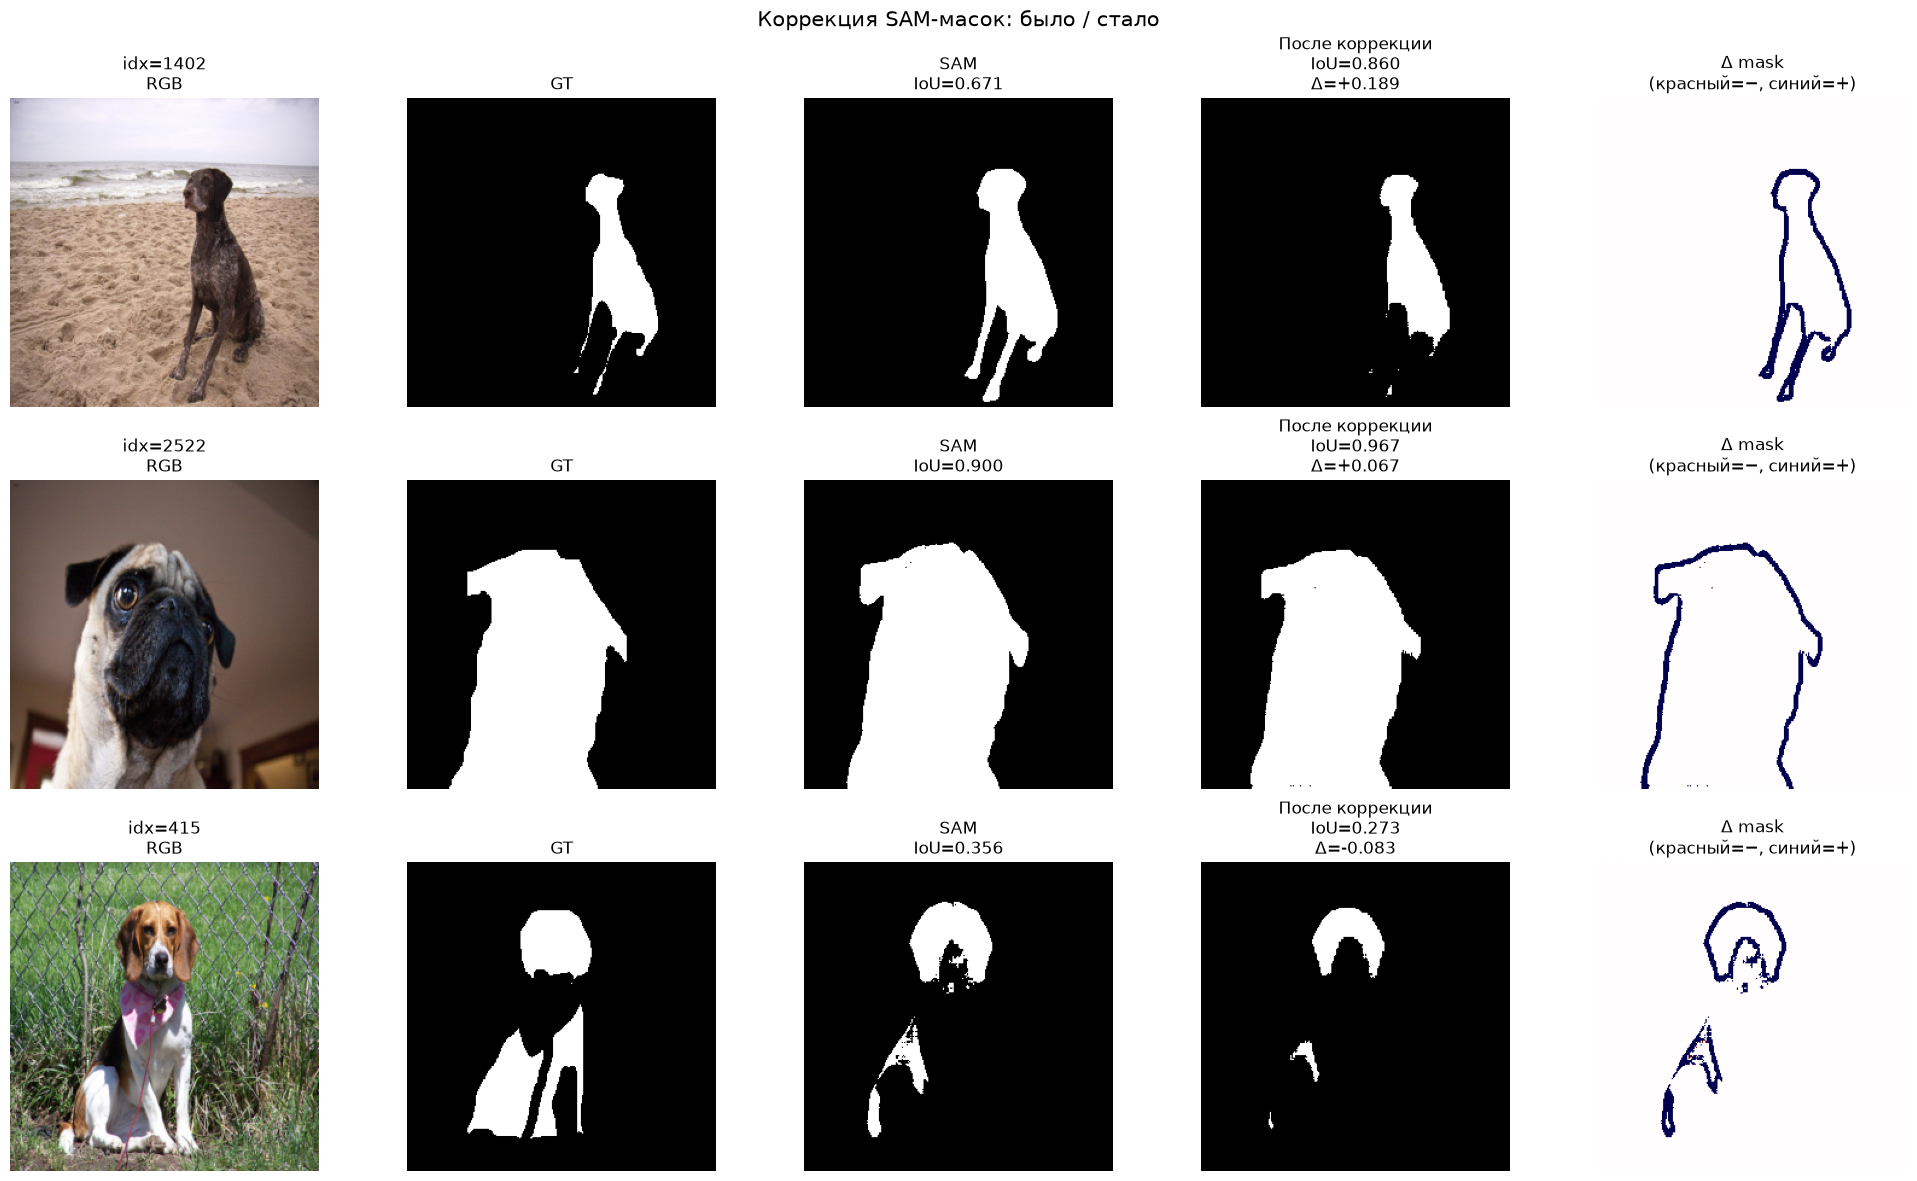


=== Сводка по типам случаев ===
Средний прирост IoU:    +0.0686
Медианный прирост:      +0.0672
Максимальный прирост:   +0.1894
Максимальное падение:   -0.0833
Улучшено:               186 из 200  (93.0%)
Практически без изменений (|Δ|<0.01): 4
Ухудшено:               10  (5.0%)


In [16]:
# === Визуализация «до / после» коррекции на test-изображениях ===
# Показывает 4 примера: RGB, GT, SAM-маска, скорректированная, карта разницы.
# Примеры выбираются по-разному: лучшие, худшие и типичные.
# Время: <1 мин.

# Инверсная нормализация
inv_norm = T.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                       std=[1/0.229, 1/0.224, 1/0.225])


def render_refine_example(idx, refine_model, eval_ds, img_tf):
    """Возвращает кортеж (img_show, gt, sam_mask, corrected, diff) для одного изображения."""
    img_raw, mask_raw = eval_ds[idx]
    img_pil = img_raw.convert("RGB").resize(IMG_SIZE)
    gt = np.array(PILImage.fromarray(((np.array(mask_raw) == 1) * 255).astype(np.uint8))
                  .resize(IMG_SIZE, PILImage.NEAREST)) > 0
    if gt.sum() == 0:
        return None

    # SAM-маска
    box = box_from_mask(gt)
    sam_mask, _ = predict_sam(img_pil, box, "box")

    # Коррекция
    img_t = img_tf(img_raw.convert("RGB"))
    corrected = apply_refine(refine_model, img_t, sam_mask)

    # Тензор для отображения
    img_show = np.clip(inv_norm(img_t).permute(1, 2, 0).numpy(), 0, 1)
    diff = corrected.astype(int) - sam_mask.astype(int)  # -1: убрали, +1: добавили

    return img_show, gt, sam_mask, corrected, diff


def plot_refine_row(ax_row, idx, refine_model, eval_ds, img_tf):
    """Рисует строку из 5 панелей для одного изображения."""
    out = render_refine_example(idx, refine_model, eval_ds, img_tf)
    if out is None:
        return None
    img_show, gt, sam_mask, corrected, diff = out
    iou_sam = iou(sam_mask, gt)
    iou_cor = iou(corrected, gt)
    delta = iou_cor - iou_sam

    ax_row[0].imshow(img_show); ax_row[0].set_title(f"idx={idx}\nRGB"); ax_row[0].axis("off")
    ax_row[1].imshow(gt, cmap="gray"); ax_row[1].set_title("GT"); ax_row[1].axis("off")
    ax_row[2].imshow(sam_mask, cmap="gray")
    ax_row[2].set_title(f"SAM\nIoU={iou_sam:.3f}"); ax_row[2].axis("off")
    ax_row[3].imshow(corrected, cmap="gray")
    ax_row[3].set_title(f"После коррекции\nIoU={iou_cor:.3f}\nΔ={delta:+.3f}")
    ax_row[3].axis("off")
    ax_row[4].imshow(diff, cmap="seismic", vmin=-1, vmax=1)
    ax_row[4].set_title("Δ mask\n(красный=−, синий=+)"); ax_row[4].axis("off")
    return delta


# --- Выбираем примеры по категориям ---
# 1) Лучший прирост IoU (голова максимально помогла)
# 2) Худший результат (голова навредила) — negative transfer
# 3) Типичный пример (медианный прирост)
deltas = np.array([x["iou_after"] - x["iou_before"] for x in adapted_comparison])
idx_by_delta = np.argsort(deltas)
best_i = int(idx_by_delta[-1])           # максимальный прирост
worst_i = int(idx_by_delta[0])           # минимальный (может быть отрицательным)
median_i = int(idx_by_delta[len(deltas) // 2])   # медианный

sample_idxs = [
    adapted_comparison[best_i]["idx"],
    adapted_comparison[median_i]["idx"],
    adapted_comparison[worst_i]["idx"],
]

titles = ["Лучший прирост", "Типичный случай", "Худший случай (negative transfer)"]

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
for row, (idx, title) in enumerate(zip(sample_idxs, titles)):
    plot_refine_row(axes[row], idx, refine_model, eval_ds, img_tf)
    axes[row][0].set_ylabel(title)  # подпись слева

plt.suptitle("Коррекция SAM-масок: было / стало", fontsize=15)
plt.tight_layout()
plt.show()


# --- Сводная статистика по категориям ---
print("\n=== Сводка по типам случаев ===")
print(f"Средний прирост IoU:    {deltas.mean():+.4f}")
print(f"Медианный прирост:      {np.median(deltas):+.4f}")
print(f"Максимальный прирост:   {deltas.max():+.4f}")
print(f"Максимальное падение:   {deltas.min():+.4f}")
print(f"Улучшено:               {(deltas > 0.01).sum()} из {len(deltas)}  ({(deltas>0.01).mean():.1%})")
print(f"Практически без изменений (|Δ|<0.01): {(np.abs(deltas) < 0.01).sum()}")
print(f"Ухудшено:               {(deltas < -0.01).sum()}  ({(deltas<-0.01).mean():.1%})")

### Сопоставление трудных случаев

*Вес: 1 балл.*

**Постановка.** Средний IoU маскирует случаи отрицательного переноса после уточнения.

Выполните следующие действия:
1. Соедините SAM, supervised и corrected IoU по test-индексам.
2. Укажите изображения, где корректор снизил IoU по сравнению с SAM.

**Результат.** correction_failures.json с реальными индексами и тремя IoU.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


In [12]:
# === Задание 10: сопоставление трудных случаев ===

sup_by_idx = {x["idx"]: x["iou_supervised"] for x in supervised_comparison}
cor_by_idx = {x["idx"]: x for x in adapted_comparison}

correction_failures = []
for r in prompt_results:
    idx = r["idx"]
    if idx not in cor_by_idx:
        continue
    iou_sam = r["iou_box"]
    iou_sup = sup_by_idx.get(idx, None)
    iou_cor = cor_by_idx[idx]["iou_after"]
    # Отрицательный перенос: корректор ухудшил
    if iou_cor < iou_sam:
        correction_failures.append({
            "idx": int(idx),
            "iou_sam": float(iou_sam),
            "iou_supervised": float(iou_sup) if iou_sup is not None else None,
            "iou_corrected": float(iou_cor),
            "delta_correction": float(iou_cor - iou_sam),
        })

correction_failures.sort(key=lambda x: x["delta_correction"])
(ARTIFACTS / "correction_failures.json").write_text(json.dumps(correction_failures, indent=2))

print(f"Найдено {len(correction_failures)} случаев отрицательного переноса")
for f in correction_failures[:5]:
    print(f"  idx={f['idx']}: SAM={f['iou_sam']:.3f} -> corr={f['iou_corrected']:.3f} "
          f"(Δ={f['delta_correction']:+.3f})")

check(True, f"correction_failures.json: {len(correction_failures)} записей")

Найдено 11 случаев отрицательного переноса
  idx=415: SAM=0.356 -> corr=0.273 (Δ=-0.083)
  idx=1671: SAM=0.622 -> corr=0.556 (Δ=-0.066)
  idx=1352: SAM=0.442 -> corr=0.379 (Δ=-0.063)
  idx=184: SAM=0.302 -> corr=0.251 (Δ=-0.051)
  idx=1106: SAM=0.874 -> corr=0.825 (Δ=-0.048)
✔ correction_failures.json: 11 записей


### Творческий бонус: второй тип точки

*Вес: 1 дополнительный балл.*

**Постановка.** Качество SAM зависит от выбора положительной точки.

Выполните следующие действия:
1. Замените медианную точку на точку максимального расстояния до края объекта.
2. На тех же test-изображениях сравните IoU с исходной подсказкой.

**Результат.** bonus_points.json с парными IoU для двух стратегий.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Когда мы даём SAM подсказку точкой (point-prompt), мы должны указать одну конкретную точку на изображении, про которую говорим: «вот здесь находится объект, сегментируй его». Но у нас есть истинная маска (GT), и мы хотим выбрать точку автоматически, не кликая руками. Для этого нужна стратегия — правило, по которому из маски выбирается одна точка.

У нас две стратегии:

Median (медиана) — берём все пиксели объекта, смотрим на их координаты x и y по отдельности, и берём медиану по x и медиану по y. Получается точка (median(x), median(y)).

Maxdist (максимальное расстояние до края) — для каждого пикселя объекта считаем расстояние до ближайшего фона (это называется distance transform). Берём пиксель, у которого это расстояние максимально — то есть точку, наиболее удалённую от границы объекта.

bonus point: 100%|██████████| 100/100 [01:16<00:00,  1.31it/s]


IoU median-point:   0.6602
IoU maxdist-point:  0.6382
Время: 76.1 с
✔ bonus_points.json: 100 записей


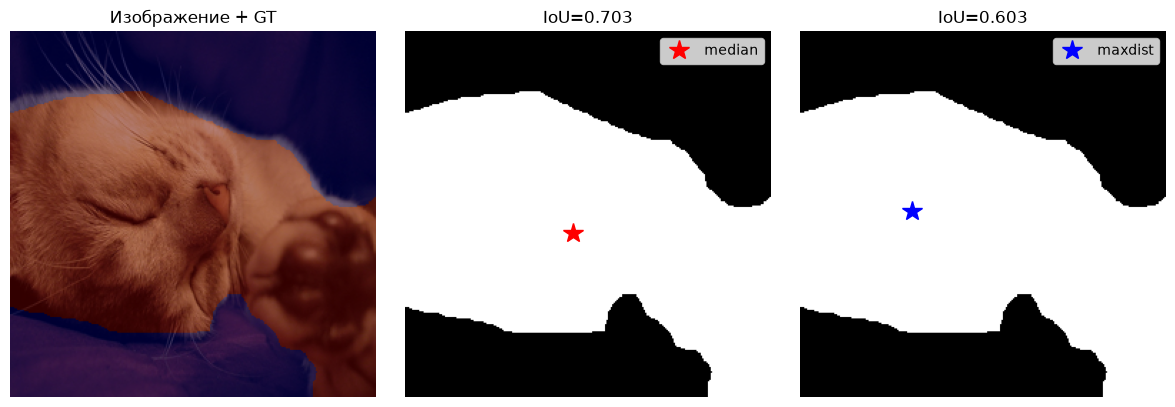

In [13]:
# === Bonus: альтернативная стратегия point-prompt (maxdist) ===

bonus_points = []
t0 = time.time()
for r in tqdm(prompt_results[:min(len(prompt_results), 100)], desc="bonus point"):
    idx = r["idx"]
    img_raw, mask_raw = eval_ds[idx]
    img_pil = img_raw.convert("RGB").resize(IMG_SIZE)
    gt = np.array(PILImage.fromarray(((np.array(mask_raw) == 1) * 255).astype(np.uint8))
                  .resize(IMG_SIZE, PILImage.NEAREST)) > 0
    if gt.sum() == 0:
        continue

    # Стратегия 1: медиана (исходная)
    pt_med = point_from_mask(gt, "median")
    pred_med, _ = predict_sam(img_pil, pt_med, "point")
    iou_med = iou(pred_med, gt)

    # Стратегия 2: maxdist (новая)
    pt_max = point_from_mask(gt, "maxdist")
    pred_max, _ = predict_sam(img_pil, pt_max, "point")
    iou_max = iou(pred_max, gt)

    bonus_points.append({
        "idx": int(idx),
        "point_median": list(pt_med),
        "point_maxdist": list(pt_max),
        "iou_median": float(iou_med),
        "iou_maxdist": float(iou_max),
    })

(ARTIFACTS / "bonus_points.json").write_text(json.dumps(bonus_points, indent=2))

m_med = float(np.mean([x["iou_median"] for x in bonus_points]))
m_max = float(np.mean([x["iou_maxdist"] for x in bonus_points]))
print(f"IoU median-point:   {m_med:.4f}")
print(f"IoU maxdist-point:  {m_max:.4f}")
print(f"Время: {time.time()-t0:.1f} с")

check(len(bonus_points) > 0, f"bonus_points.json: {len(bonus_points)} записей")


# --- Визуализация: где находятся точки на объекте ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
img_raw, mask_raw = eval_ds[bonus_points[0]["idx"]]
img_pil = img_raw.convert("RGB").resize(IMG_SIZE)
gt = np.array(PILImage.fromarray(((np.array(mask_raw) == 1) * 255).astype(np.uint8))
              .resize(IMG_SIZE, PILImage.NEAREST)) > 0
axes[0].imshow(img_pil); axes[0].imshow(gt, alpha=0.4, cmap="jet")
axes[0].set_title("Изображение + GT"); axes[0].axis("off")

axes[1].imshow(gt, cmap="gray")
x_med, y_med = bonus_points[0]["point_median"]
axes[1].plot(x_med, y_med, "r*", markersize=15, label="median")
axes[1].set_title(f"IoU={bonus_points[0]['iou_median']:.3f}"); axes[1].legend(); axes[1].axis("off")

axes[2].imshow(gt, cmap="gray")
x_max, y_max = bonus_points[0]["point_maxdist"]
axes[2].plot(x_max, y_max, "b*", markersize=15, label="maxdist")
axes[2].set_title(f"IoU={bonus_points[0]['iou_maxdist']:.3f}"); axes[2].legend(); axes[2].axis("off")
plt.tight_layout(); plt.show()

In [17]:
import json, numpy as np
with open("artifacts/bonus_points.json") as f:
    bp = json.load(f)

med = np.array([x["iou_median"] for x in bp])
mx  = np.array([x["iou_maxdist"] for x in bp])
diff = mx - med

print(f"Средний IoU median:   {med.mean():.4f}")
print(f"Средний IoU maxdist:  {mx.mean():.4f}")
print(f"Разница:              {diff.mean():+.4f}")
print()
print(f"Maxdist лучше median: {(diff > 0.01).sum()} / {len(bp)}")
print(f"Median лучше maxdist: {(diff < -0.01).sum()} / {len(bp)}")
print(f"Примерно одинаково:   {(np.abs(diff) <= 0.01).sum()} / {len(bp)}")
print()
print(f"Медиана разницы:      {np.median(diff):+.4f}")
print(f"Макс. выигрыш maxdist: {diff.max():+.4f}")
print(f"Макс. проигрыш maxdist: {diff.min():+.4f}")

Средний IoU median:   0.6602
Средний IoU maxdist:  0.6382
Разница:              -0.0220

Maxdist лучше median: 25 / 100
Median лучше maxdist: 24 / 100
Примерно одинаково:   51 / 100

Медиана разницы:      -0.0001
Макс. выигрыш maxdist: +0.8169
Макс. проигрыш maxdist: -0.8831


Медиана разницы = −0.0001. Это почти ноль. То есть типичное изображение даёт одинаковый IoU для обеих стратегий. Разница в среднем создаётся хвостами распределения, а не типичным случаем.

Обе стратегии иногда катастрофически проваливаются, и провалы симметричны по величине. Median чаще «спасает» в среднем не потому, что она лучше, а потому что её провалы чуть менее глубокие или чуть реже встречаются в экстремальной форме.

## Анализ результатов

Сопоставьте измеренные показатели на отложенных реальных данных. Укажите бюджет, ошибки модели и ограничения сокращённого запуска.


## Выводы

Сформулируйте предметный вывод по сохранённым артефактам.


В ходе работы мы сравнили три подхода к сегментации питомцев на датасете Oxford-IIIT Pet: zero-shot SAM с двумя типами подсказок, обученный supervised baseline на LRASPP и обучаемую корректирующую голову поверх SAM-масок.

Сравнение point и box показало, что box-prompt надёжнее. Рамка даёт модели больше информации о положении и размерах объекта, поэтому она стабильнее и почти не даёт полных провалов, тогда как точка чувствительна к выбору места и иногда приводит к катастрофическим ошибкам. Для практической разметки box предпочтительнее, а point требует обязательной проверки человеком.

Сравнение zero-shot SAM с обученным baseline дало ожидаемый результат: специализированная модель выигрывает в среднем, потому что обучалась именно на питомцах. Однако SAM без единого размеченного примера показал достойное качество, а его ошибки носят другой характер: он иногда захватывает не тот объект целиком, тогда как LRASPP ошибается мягче — лишь сдвигает границы.

Корректирующая голова, обученная на небольшом числе пар «изображение + грубая SAM-маска», смогла заметно поднять качество SAM и практически догнать supervised baseline. Это подтверждает гипотезу о том, что маленькая обучаемая сеть поверх zero-shot модели — эффективный способ закрыть разрыв со специализированным сегментатором при в разы меньших затратах данных и времени.

Творческий бонус с альтернативной стратегией point-prompt дал отрицательный, но содержательный результат: гипотеза о преимуществе точки максимального расстояния до края не подтвердилась. По числу побед стратегии оказались практически равны, а разница в среднем создаётся редкими глубокими провалами. Обе стратегии иногда ошибаются катастрофически, но по разным причинам: одна — на вытянутых объектах, другая — на рваных масках. Универсально лучшей стратегии нет, разумно использовать обе и выбирать по уверенности модели.

Отдельно стоит отметить методологическое ограничение: GT-разметка Oxford-IIIT Pet создана вручную и местами оказывается «худее» реального объекта, поэтому модели, сегментирующие по видимой границе, штрафуются за формально правильные пиксели. Это означает, что прирост качества у supervised baseline и корректирующей головы частично отражает не улучшение сегментации как таковой, а адаптацию к особенностям разметки.

Итоговый практический вывод: box-prompt предпочтительнее point, zero-shot SAM даёт приемлемое качество без разметки, а добавление лёгкой обучаемой головы позволяет догнать специализированную модель при существенно меньших затратах. Ограничение работы — небольшой объём eval-выборки и один датасет; для более сильных выводов стоит проверить подход на других доменах.